In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import sys
from pathlib import Path
sys.path.insert(0, str(Path("../../scripts").resolve()))
import graph_export

plt.rcParams.update({"font.size": 14})

df = pd.read_csv("../../../results/1_process/1_filter/hapax_overlap.csv")
df.head()

,lang,file_a,file_b,hapaxes_a,hapaxes_b,overlap,share_a_pct,share_b_pct
0,abk,abk_glot500_cyrl.csv,abk_wikipedia_2012_20260404141204.csv,585598,5843,812,0.14,13.90
1,abk,abk_glot500_cyrl.csv,abk_wikipedia_2021_20260404141210.csv,585598,11922,3353,0.57,28.12
2,abk,abk_wikipedia_2012_20260404141204.csv,abk_wikipedia_2021_20260404141210.csv,5843,11922,1632,27.93,13.69
3,ace,ace_glot500_latn.csv,ace_wikipedia_2021_20260404141234.csv,41805,8862,2645,6.33,29.85
4,ach,ach_glot500_latn.csv,ach_newscrawl_2011_20260404141239.csv,1162,862,567,48.80,65.78


In [2]:
max_share_a = df.groupby("file_a")["share_a_pct"].max()
max_share_b = df.groupby("file_b")["share_b_pct"].max()

all_files = set(max_share_a.index) | set(max_share_b.index)
max_shares = {}
for f in all_files:
    vals = []
    if f in max_share_a.index:
        vals.append(max_share_a[f])
    if f in max_share_b.index:
        vals.append(max_share_b[f])
    max_shares[f] = max(vals)

shares = pd.Series(max_shares, name="max_share_pct").sort_values(ascending=False)
print(f"Files: {len(shares)}")
shares.describe()

Files: 1342


count    1342.000000
mean       22.942012
std        20.982908
min         0.000000
25%         8.312500
50%        14.670000
75%        35.740000
max       100.000000
Name: max_share_pct, dtype: float64

In [3]:
ignored_df = pd.read_csv("../../../results/1_process/1_filter/ignored_files.csv")
ignored_files = set(ignored_df["filename"])

df_filtered = df[~df["file_a"].isin(ignored_files) & ~df["file_b"].isin(ignored_files)]

max_share_a_f = df_filtered.groupby("file_a")["share_a_pct"].max()
max_share_b_f = df_filtered.groupby("file_b")["share_b_pct"].max()

all_files_f = set(max_share_a_f.index) | set(max_share_b_f.index)
max_shares_f = {}
for f in all_files_f:
    vals = []
    if f in max_share_a_f.index:
        vals.append(max_share_a_f[f])
    if f in max_share_b_f.index:
        vals.append(max_share_b_f[f])
    max_shares_f[f] = max(vals)

shares_filtered = pd.Series(max_shares_f, name="max_share_pct").sort_values(ascending=False)
print(f"Files (after ignoring {len(ignored_files)}): {len(shares_filtered)}")
shares_filtered.describe()

Files (after ignoring 300): 1012


count    1012.000000
mean       11.306670
std         7.651276
min         0.000000
25%         5.387500
50%        11.340000
75%        15.000000
max        33.110000
Name: max_share_pct, dtype: float64

graph_export: saved hapax_overlap.pdf


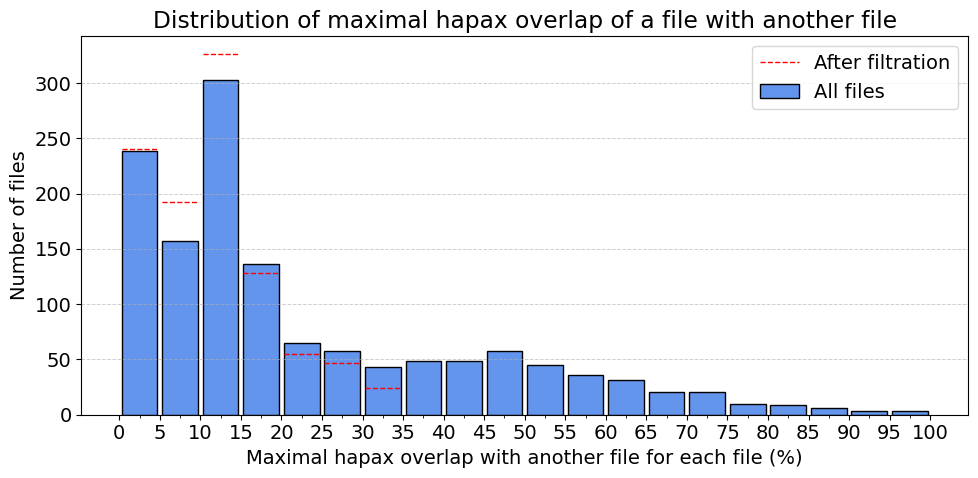

In [4]:
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))
bin_edges = np.arange(0, 105, 5)
width = 4.4

counts_all, _ = np.histogram(shares, bins=bin_edges)
counts_filt, _ = np.histogram(shares_filtered, bins=bin_edges)
centers = (bin_edges[:-1] + bin_edges[1:]) / 2

ax.bar(centers, counts_all, width=width, color="cornflowerblue",
       edgecolor="black", alpha=1, label="All files")

for c, cnt in zip(centers, counts_filt):
    if cnt > 0:
        ax.plot([c - width / 2, c + width / 2], [cnt, cnt],
                color="red", linewidth=1, linestyle="--", zorder=5)
ax.plot([], [], color="red", linewidth=1, linestyle="--", label="After filtration")

ax.set_xlabel("Maximal hapax overlap with another file for each file (%)")
ax.set_ylabel("Number of files")
ax.set_title("Distribution of maximal hapax overlap of a file with another file")
ax.set_xticks(range(0, 105, 5))
ax.set_xticks([i * 2.5 for i in range(41)], minor=True)
ax.grid(which="major", axis="y", linestyle="--", linewidth=0.7, alpha=0.6)
ax.legend()
plt.tight_layout()
graph_export.save("hapax_overlap", fig)
plt.show()

graph_export: saved dominant_script_share.pdf


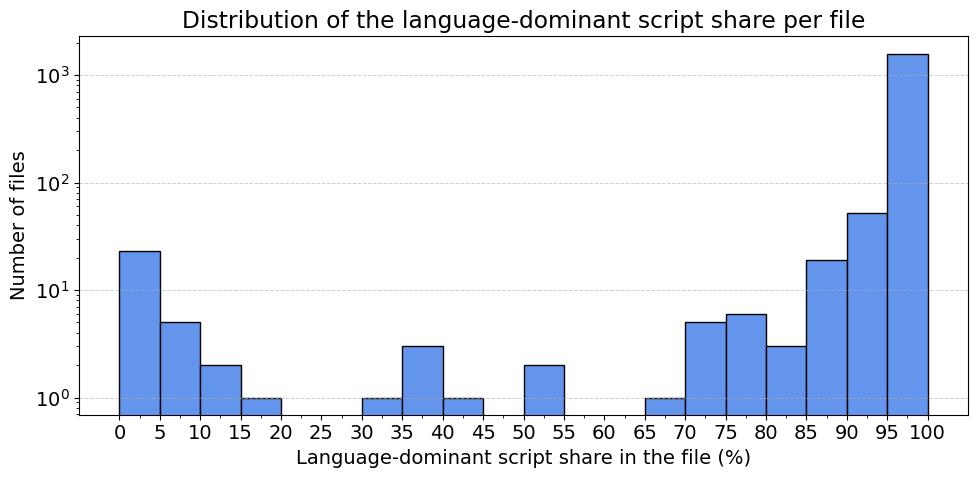

In [5]:
script_all_df = pd.read_csv("../../../results/1_process/1_filter/script_check_all.csv")

fig, ax = plt.subplots(figsize=(10, 5))
bin_edges = np.arange(0, 105, 5)

ax.hist(script_all_df["language_script_share"], bins=bin_edges,
        color="cornflowerblue", edgecolor="black")

ax.set_yscale("log")
ax.set_xlabel("Language-dominant script share in the file (%)")
ax.set_ylabel("Number of files")
ax.set_title("Distribution of the language-dominant script share per file")
ax.set_xticks(range(0, 105, 5))
ax.set_xticks([i * 2.5 for i in range(41)], minor=True)
ax.grid(which="major", axis="y", linestyle="--", linewidth=0.7, alpha=0.6)
plt.tight_layout()
graph_export.save("dominant_script_share", fig)
plt.show()